In [47]:
import tensorflow as tf
print("Tensorflow version:", tf.__version__)
import numpy as np
import matplotlib.pyplot as plt
import os
import time

Tensorflow version: 2.7.0


In [48]:
#setting path
dirname = os.getcwd()
data_storerage = os.path.join(dirname, 'data\\')
print(data_storerage)

c:\Users\whylo\Desktop\MITA_Second_Year\NNDL\hw\hw2\data\


In [49]:
#load data
a = list()
b = list()
file_size = 20
filenames = ['full_numpy_bitmap_alarm clock.npy', 'full_numpy_bitmap_ant.npy', 'full_numpy_bitmap_bear.npy', 'full_numpy_bitmap_bicycle.npy', 'full_numpy_bitmap_bowtie.npy', 'full_numpy_bitmap_calculator.npy',
'full_numpy_bitmap_camel.npy', 'full_numpy_bitmap_car.npy', 'full_numpy_bitmap_cat.npy', 'full_numpy_bitmap_coffee cup.npy', 'full_numpy_bitmap_crocodile.npy', 'full_numpy_bitmap_crown.npy', 'full_numpy_bitmap_dragon.npy',
'full_numpy_bitmap_duck.npy', 'full_numpy_bitmap_elephant.npy', 'full_numpy_bitmap_eye.npy', 'full_numpy_bitmap_fan.npy', 'full_numpy_bitmap_fish.npy', 'full_numpy_bitmap_hand.npy', 'full_numpy_bitmap_house.npy']
i=0
for i in range(20):
    datasets_example=np.array(np.load(data_storerage+filenames[i]))
    temp_list = list(datasets_example)
    a = a + temp_list
    b = b+ [i]*np.shape(temp_list)[0]


In [50]:
sample = np.array(a)
label = np.array(b)


In [51]:
#shuffle 
shuffler = np.random.permutation(range(sample.shape[0]))
sample = sample[shuffler]
label = label[shuffler]


In [52]:
#setting test and train set
from keras.utils.np_utils import to_categorical
train_sample= sample[0:105000,:]
test_sample= sample[105000:125000,:]

train_label = label[0:105000]
test_label = label[105000:125000]
print(test_label[0])
train_label = to_categorical(train_label) # The target variable should be categorical
test_label = to_categorical(test_label)

9


In [53]:
# validation_split = 4750
# train_label_use = train_sample[0:validation_split]
# train_sample_use = train_sample[0:validation_split,:]

# train_label_sv = train_sample[validation_split:]
# train_sample_sv = train_sample[validation_split:,:]

In [54]:
from tensorflow import  keras
from keras import models
from keras import layers
from keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization
p = 0.4

network=models.Sequential()

network.add(layers.Dense(512,activation='relu',input_shape = (28*28,)))
#network.add(BatchNormalization())
network.add(Dropout(p))

network.add(layers.Dense(512,activation='relu'))
#network.add(BatchNormalization())
network.add(Dropout(p))

network.add(layers.Dense(512,activation='relu'))
#network.add(BatchNormalization())
network.add(Dropout(p))


network.add(layers.Dense(512,activation='relu'))
#network.add(BatchNormalization())
network.add(Dropout(p))

network.add(layers.Dense(20,activation='softmax'))

optimizer = tf.keras.optimizers.SGD(momentum=0.5,learning_rate=0.05)

network.compile(optimizer=optimizer,loss='categorical_crossentropy',metrics=['accuracy'])

train_sample = train_sample.reshape(np.shape(train_sample)[0],28*28)
train_sample = train_sample.astype('float32')/255
test_sample = test_sample.reshape(np.shape(test_sample)[0],28*28)
test_sample = test_sample.astype('float32')/255



validation_split = 100000
train_label_use = train_label[0:validation_split]
train_sample_use = train_sample[0:validation_split,:]

train_label_sv = train_label[validation_split:]
train_sample_sv = train_sample[validation_split:,:]


#early stop
early_stopping = keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True)
history=network.fit(train_sample_use, train_label_use, 
                    validation_data=(train_sample_sv,train_label_sv),
                    epochs=300, batch_size=128,
                    callbacks=[early_stopping]
                    )
test_loss, test_acc=network.evaluate(test_sample, test_label) #Apply the learned network to the test data
print('test_acc:',test_acc) 
predProb=network.predict(test_sample) # probabilities of digits
pred=list(map(np.argmax,predProb))


Epoch 1/300
782/782 [==============================] - 11s 14ms/step - loss: 2.0358 - accuracy: 0.3873 - val_loss: 1.4851 - val_accuracy: 0.5630
Epoch 2/300
782/782 [==============================] - 10s 13ms/step - loss: 1.5391 - accuracy: 0.5520 - val_loss: 1.2536 - val_accuracy: 0.6336
Epoch 3/300
782/782 [==============================] - 10s 13ms/step - loss: 1.3688 - accuracy: 0.6056 - val_loss: 1.1626 - val_accuracy: 0.6626
Epoch 4/300
782/782 [==============================] - 9s 11ms/step - loss: 1.2612 - accuracy: 0.6366 - val_loss: 1.0766 - val_accuracy: 0.6886
Epoch 5/300
782/782 [==============================] - 10s 13ms/step - loss: 1.1830 - accuracy: 0.6596 - val_loss: 1.0178 - val_accuracy: 0.7104
Epoch 6/300
782/782 [==============================] - 10s 13ms/step - loss: 1.1228 - accuracy: 0.6769 - val_loss: 0.9707 - val_accuracy: 0.7176
Epoch 7/300
782/782 [==============================] - 9s 12ms/step - loss: 1.0707 - accuracy: 0.6911 - val_loss: 0.9423 - val_accu

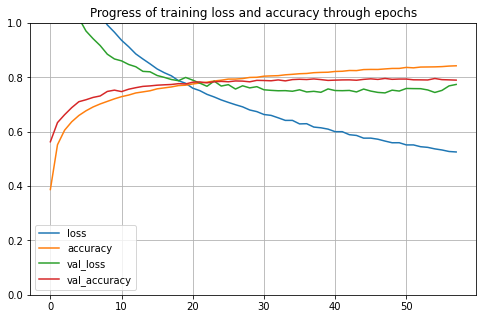

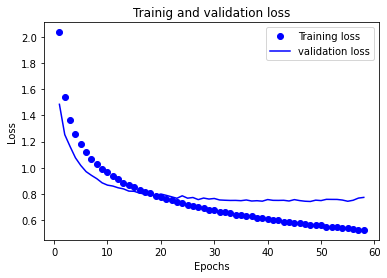

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.title("Progress of training loss and accuracy through epochs")
plt.show()

history_dic = history.history
loss_values=history_dic['loss']
validation_loss_values=history_dic['val_loss']
#plot prgress of training and validation loss/accuracy
epochs = range(1,len(loss_values)+1)
plt.plot(epochs, loss_values, 'bo', label="Training loss")
plt.plot(epochs,validation_loss_values,'b',label="validation loss")
plt.title("Trainig and validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [56]:
from sklearn.metrics import confusion_matrix, accuracy_score
pred_prob=np.stack([network(test_sample, training=True) for sample in range(100)])
pred_prob1=network.predict(test_sample)




---
*Using the MC Dropout or MC Drop out could randomly choose some of the weight out of the Nerual Network to reduce the overfitting problem in order to achieve the geral better performance on both testing and traing data.*

*And we can see a small improvment of using the MC Dropout.*

In [57]:
pred=pred_prob.mean(axis=0)
pred1=pred_prob1
pred_label=np.argmax(pred,1)

test_label = label[105000:125000]

print(f"Accuracy for prediction without MC: {accuracy_score(test_label,list(map(tf.argmax,pred1))):3.4f}")
print(f"Accuracy for prediction with MC: {accuracy_score(test_label,list(map(tf.argmax,pred))):3.4f}")



Accuracy for prediction without MC: 0.7829
Accuracy for prediction with MC: 0.7848


In [58]:
#sv for reuse
network.save(dirname+'\\model')

INFO:tensorflow:Assets written to: c:\Users\whylo\Desktop\MITA_Second_Year\NNDL\hw\hw2\model\assets
